In [1]:
# For processing the timeseries
import pandas as pd, os, datetime
import numpy as np

# For plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
pio.renderers.default = 'notebook'

# For clustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import MinMaxScaler

In [2]:
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')

nmap_path = '/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess'
ehf_fpath = '/scratch/ng72/ms5578/time_series'
gen_fpath = '/scratch/ng72/ms5578/time_series/nem_generation'

In [3]:
sdate, edate = '2009-07-01','2024-06-30'

In [4]:
gen_details = pd.read_csv(f"{nmap_path}/gen_info.csv",index_col=False)
nmap = pd.read_csv(f"{nmap_path}/gen_info.csv",index_col=False)
hw_tseries = pd.read_csv(f"{ehf_fpath}/gen_hw_status.csv",index_col=False)

In [5]:
def process_group(grp, gen_fpath, hw_tseries, start_date=sdate, end_date=edate):
    """
    Processes a single group of generator data.

    Parameters:
        grp (pd.DataFrame): A single group from gen_details (e.g., from groupby('region')).
        gen_fpath (str): Path to directory containing CSV files named by DUID (e.g., DUID.csv).
        hw_tseries (pd.DataFrame): DataFrame with columns 'time', 'DUID', and data to merge.
        start_date (str): Start date for subsetting the time series.
        end_date (str): End date for subsetting the time series.

    Returns:
        pd.DataFrame: The merged result for the group.
    """
    gen_locs = gen_fpath + '/' + grp['DUID'] + ".csv"
    dfs = [pd.read_csv(fp,dtype='object') for fp in gen_locs if os.path.exists(fp)]

    if not dfs:
        return None

    # This is in case of accidental mid-file headers
    dfs = pd.concat(dfs, ignore_index=True)
    header_row = dfs.columns.tolist()
    dfs = dfs[~dfs.apply(lambda row: list(row) == header_row, axis=1)]

    # This is to correct the column types after removing header rows
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs['TOTALCLEARED'] = dfs['TOTALCLEARED'].astype(float)
    dfs['TOTALMWh'] = dfs['TOTALMWh'].astype(float)
    dfs['AGCSTATUS'] = pd.to_numeric(dfs['AGCSTATUS'], errors='coerce').fillna(0).astype(int)
    
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs = dfs.set_index('time').sort_index()
    dfs = dfs.loc[start_date:end_date]

    hw_tseries['time'] = pd.to_datetime(hw_tseries['time'])
    hw_tseries = hw_tseries.set_index(['time']).sort_index()
    hw_tseries = hw_tseries.loc[sdate:edate]
    hw_tseries = hw_tseries.reset_index().set_index(['DUID','time']).sort_index()

    merged = pd.merge_asof(
        dfs.sort_values(by=['time', 'DUID']),
        hw_tseries.sort_values(by=['time', 'DUID']),
        by='DUID',
        on='time',
        tolerance=pd.Timedelta("1d"),
        direction='nearest'
    )

    return merged

In [6]:
def clean_df(df,
             t1='00:00:00',
             t2='23:59:59',
             hw=False,
             gen_details=gen_details,
             AGC=False,
             summer=False):
    
    df = df.merge(gen_details[['DUID', 'reg_cap_generation_mw']], on='DUID', how='left')
    df['reg_cap_generation_mw'] = df['reg_cap_generation_mw'].astype('float')
    df['cap_norm'] = df['TOTALMWh']/df['reg_cap_generation_mw']
    df = df[~((df['cap_norm'] > 1) | (df['cap_norm'] <0)) ]

    df_sliced = df
    
    # Looking at summer generation profiles
    if summer == True:
        df_sliced = df.loc[(df['time'].dt.month >= 11)| (df['time'].dt.month <= 3)].set_index('time')
        df_sliced = df_sliced.between_time(t1,t2).reset_index()

    if hw == True:
        df_sliced = df_sliced[df_sliced['EHF_flag'] == 1]

    if AGC == True:
        df_sliced = df_sliced[df_sliced['AGCSTATUS'] == 1]
    
    return df_sliced

In [27]:
ft_groups = gen_details.groupby(['region'])
grp = ft_groups.get_group(('VIC1',))

# df_hw = process_group(grp, gen_fpath, hw_tseries)
df_hw = hw_tseries

In [28]:
nmap = nmap[nmap.DUID.isin(df_hw['DUID'])]
df_hw = pd.merge(nmap[['DUID','fuel_source_primary']], df_hw, on='DUID').dropna()

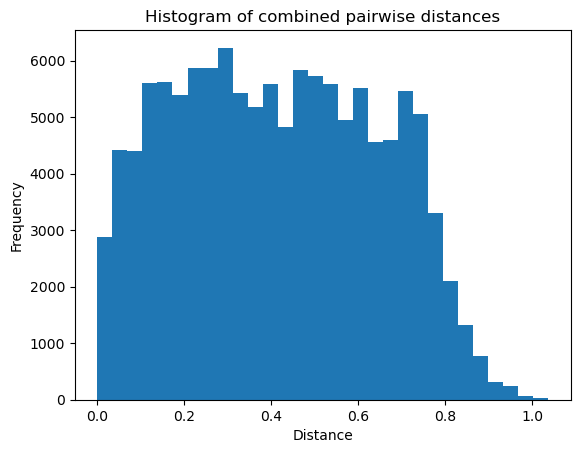

In [31]:
def cluster_heatwave_patterns(df, eps, alpha=0.5, min_samples=2):
    """
    Perform spatiotemporal clustering on EHF_flag patterns and coordinates.
    
    Parameters:
        df (pd.DataFrame): Must contain ['DUID', 'time', 'EHF_flag', 'lat', 'lon']
        eps (float): DBSCAN epsilon
        alpha (float): Weight for heatwave pattern (1.0 = only EHF, 0.0 = only spatial)
        min_samples (int): Minimum samples per cluster
        
    Returns:
        pd.DataFrame: Original df with a 'cluster' column added
    """
    # --- Step 1: Pivot to get [points x time] matrix ---
    matrix = df.pivot(index='DUID', columns='time', values='EHF_flag').fillna(0).astype(int)

    # --- Step 2: Compute time-based distance ---
    dist_time = pairwise_distances(matrix, metric='hamming')  # or 'jaccard'

    # --- Step 3: Get lat/lon and normalize ---
    coords = df[['DUID', 'lat', 'lon']].drop_duplicates().set_index('DUID').loc[matrix.index]
    coords_scaled = MinMaxScaler().fit_transform(coords)

    # --- Step 4: Compute spatial distance ---
    dist_space = pairwise_distances(coords_scaled, metric='euclidean')

    # --- Step 5: Combine the two distances ---
    dist_combined = alpha * dist_time + (1-alpha) * dist_space

    dists = dist_combined[np.triu_indices_from(dist_combined, k=1)]

    plt.hist(dists, bins=30)
    plt.title("Histogram of combined pairwise distances")
    plt.xlabel("Distance")
    plt.ylabel("Frequency")
    plt.show()
    
    # --- Step 6: DBSCAN clustering ---
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = db.fit_predict(dist_combined)

    # --- Step 7: Attach cluster labels ---
    matrix['cluster'] = labels
    out = df.merge(matrix['cluster'], on='DUID')

    return out

# --- Run the function ---
clustered_df = cluster_heatwave_patterns(df_hw, eps=0.02, alpha=0, min_samples=3)

In [32]:
df_plot = clustered_df.copy()
df_plot['cluster'] = df_plot['cluster'].astype(str)

fig = px.scatter_map(
    df_plot,
    lat='lat',
    lon='lon',
    color='cluster',
    color_discrete_sequence=px.colors.qualitative.Light24,
    hover_name='DUID',
    hover_data=['time','fuel_source_primary'],
    zoom=2,
    map_style='carto-positron',
    title='Heatwave Clusters by DBSCAN'
)

fig.show()

In [ ]:
def summarize_heatwave_clusters(df, cluster_col='cluster', time_col='time', unit_col='DUID', flag_col='EHF_flag'):
    """
    Computes heatwave synchrony metrics for all clusters:
    - percent_full: all units in sync
    - percent_majority: ≥50% of units in sync

    Returns:
        A summary DataFrame with one row per cluster.
    """
    records = []
    clusters = df[cluster_col].dropna().unique()

    for cluster_id in clusters:
        cluster_df = df[df[cluster_col] == cluster_id].copy()
        
        matrix = cluster_df.pivot(index=time_col, columns=unit_col, values=flag_col).fillna(0)

        total_days = matrix.shape[0]
        n_units = matrix.shape[1]
        daily_sum = matrix.sum(axis=1)

        # FULL: all points in heatwave
        n_full_days = (daily_sum == n_units).sum()

        # MAJORITY: at least 50% of points in heatwave
        majority_threshold = n_units / 2
        n_majority_days = (daily_sum >= majority_threshold).sum()

        percent_full = n_full_days / total_days if total_days > 0 else 0.0
        percent_majority = n_majority_days / total_days if total_days > 0 else 0.0

        records.append({
            'cluster': cluster_id,
            'n_units': n_units,
            'total_days': total_days,
            'n_full_days': n_full_days,
            'percent_full': percent_full,
            'n_majority_days': n_majority_days,
            'percent_majority': percent_majority
        })

    return pd.DataFrame(records).sort_values('percent_majority', ascending=False).reset_index(drop=True)


In [ ]:
summary = summarize_heatwave_clusters(clustered_df)

fig = px.bar(
    summary,
    x='cluster',
    y='percent_majority',
    title='Majority Heatwave Synchrony per Cluster',
    labels={'percent_majority': '≥50% in Heatwave'},
    text=summary['percent_majority'].apply(lambda x: f"{x:.1%}")
)

fig.update_traces(textposition='outside')
fig.update_layout(yaxis_tickformat='.0%', yaxis_range=[0, 1])
fig.show()

fig.write_html('/g/data/ng72/ms5578/ID_HW_BARRA/data/output/plots/dbscan_clusters.png')

In [ ]:
summary

In [ ]:
summary['n_units'].sum()